<center>
## Открытый курс по машинному обучению.
</center>
Автор материала: программист-исследователь Mail.ru Group, старший преподаватель Факультета Компьютерных Наук ВШЭ Юрий Кашницкий. Материал распространяется на условиях лицензии [Creative Commons CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/). Можно использовать в любых целях (редактировать, поправлять и брать за основу), кроме коммерческих, но с обязательным упоминанием автора материала.

# <center>Тема 1. Первичный анализ данных с Pandas</center>
## <center>Практическое задание. Анализ данных пассажиров "Титаника"</center>

**Заполните код в клетках (где написано "Ваш код здесь")


In [8]:
import numpy as np
import pandas as pd
%matplotlib inline

In [9]:
!ls #Посмотрите, что находится в текущей диретории

part_1.ipynb  part_2  titanic_train  titanic_train.csv


In [10]:
!pwd #Посмотрите путь до текущей диретории

/home/viktor/Projects/data_science/L1


**Считаем данные из файла в память в виде объекта Pandas.DataFrame**

In [11]:
data = pd.read_csv('titanic_train.csv',
                  index_col='PassengerId')

**Данные представлены в виде таблицы. Посмотрим на первые 5 строк:**

In [12]:
data.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Для примера отберем пассажиров, которые сели в Cherbourg (Embarked=C) и заплатили более 200 у.е. за билет (fare > 200).**

Убедитесь, что Вы понимаете, как эта конструкция работает. <br>
Если нет – посмотрите, как вычисляется выражение в квадратных в скобках.

In [14]:
data[(data['Embarked'] == 'C') & (data.Fare > 200)].head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
119,0,1,"Baxter, Mr. Quigg Edmond",male,24.0,0,1,PC 17558,247.5208,B58 B60,C
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
378,0,1,"Widener, Mr. Harry Elkins",male,27.0,0,2,113503,211.5000,C82,C


**Можно отсортировать этих людей по убыванию платы за билет.**

In [15]:
data[(data['Embarked'] == 'C') &
     (data['Fare'] > 200)].sort_values(by='Fare',
                               ascending=False).head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


**Пример создания признака.**

In [16]:
def age_category(age):
    '''
    < 30 -> 1
    >= 30, <55 -> 2
    >= 55 -> 3
    '''
    if age < 30:
        return 1
    elif age < 55:
        return 2
    else:
        return 3

In [17]:
age_categories = [age_category(age) for age in data.Age]

In [18]:
data['Age_category'] = age_categories

**Другой способ – через `apply`.**

In [19]:
data['Age_category'] = data['Age'].apply(age_category)

**1. Сколько мужчин / женщин находилось на борту?**
- 412 мужчин и 479 женщин
- 314 мужчин и 577 женщин
- 479 мужчин и 412 женщин
- 577 мужчин и 314 женщин +

In [20]:
data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [21]:
data.groupby('Sex').agg({'Name':'count'})

,Name
Sex,
female,314
male,577


**2. Выведите распределение переменной `Pclass` (социально-экономический статус) и это же распределение, только для мужчин / женщин по отдельности. Сколько было мужчин 2-го класса?**
- 104
- 108 +
- 112
- 125

In [ ]:
pdata = data.groupby('Pclass').agg({'Name':'count'})
pdata

,Name
Pclass,
1,216
2,184
3,491


In [23]:
data.groupby(['Pclass', 'Sex']).agg({'Name':'count'})

Name
Pclass Sex         
1      female    94
       male     122
2      female    76
       male     108
3      female   144
       male     347

**3. Каковы медиана и стандартное отклонение платежей (`Fare`)? Округлите до 2 десятичных знаков.**
- Медиана – 14.45, стандартное отклонение – 49.69 +
- Медиана – 15.1, стандартное отклонение – 12.15
- Медиана – 13.15, стандартное отклонение – 35.3
- Медиана – 17.43, стандартное отклонение – 39.1

In [ ]:
median = data['Fare'].median()
std = data['Fare'].std()
print(f'Медиана: {round(median, 2)}\nСтанадртное отклонение: {round(std, 2)}')


Медиана: 14.45
Станадртное отклонение: 49.69


**4. Правда ли, что люди моложе 30 лет выживали чаще, чем люди старше 60 лет? Каковы доли выживших в обеих группах?**
- 22.7% среди молодых и 40.6% среди старых
- 40.6% среди молодых и 22.7% среди старых +
- 35.3% среди молодых и 27.4% среди старых
- 27.4% среди молодых и 35.3% среди старых

In [ ]:
young_alive = data[(data['Age'] < 30) & (data['Survived'] == 1)]['Name'].count()
young = data[(data['Age'] < 30)]['Name'].count()
old_alive = data[(data['Age'] > 60) & (data['Survived'] == 1)]['Name'].count()
old = data[(data['Age'] > 60)]['Name'].count()
persent_young_alive = (young_alive / young) * 100
persdt_old_alive = (old_alive / old) * 100
print(f'{round(persent_young_alive, 1)}% среди молодых и {round(persent_young_alive, 1)}% среди старых')

40.6% среди молодых и 40.6% среди старых


**5. Правда ли, что женщины выживали чаще мужчин? Каковы доли выживших в обеих группах?**
- 30.2% среди мужчин и 46.2% среди женщин
- 35.7% среди мужчин и 74.2% среди женщин
- 21.1% среди мужчин и 46.2% среди женщин
- 18.9% среди мужчин и 74.2% среди женщин +

In [ ]:
males = data[data['Sex'] == 'male']['Name'].count()
males_alive = data[(data['Sex'] == 'male') & (data['Survived'] == 1)]['Name'].count()
females = data[data['Sex'] == 'female']['Name'].count()
females_alive = data[(data['Sex'] == 'female') & (data['Survived'] == 1)]['Name'].count()
persent_males_alive = (males_alive / males) * 100
persent_females_alive = (females_alive / females) * 100
print(f'{round(persent_males_alive, 1)}% среди мужчин и {round(persent_females_alive, 1)}% среди женщин')

18.9% среди мужчин и 74.2% среди женщин


**6. Найдите самое популярное имя среди пассажиров Титаника мужского пола?**
- Charles
- Thomas
- William +
- John

In [ ]:
import re
males = data[data['Sex'] == 'male'].copy()
males['f_name'] = males['Name'].apply(lambda name: (re.sub(r'^.*\b(Mr|Don|Master)\.', '', name)).split()[0])
males['f_name'].value_counts().head(1)

f_name
William    34
Name: count, dtype: int64

**7. Сравните графически распределение стоимости билетов и возраста у спасенных и у погибших. Средний возраст погибших выше, верно?**
- Да
- Нет +

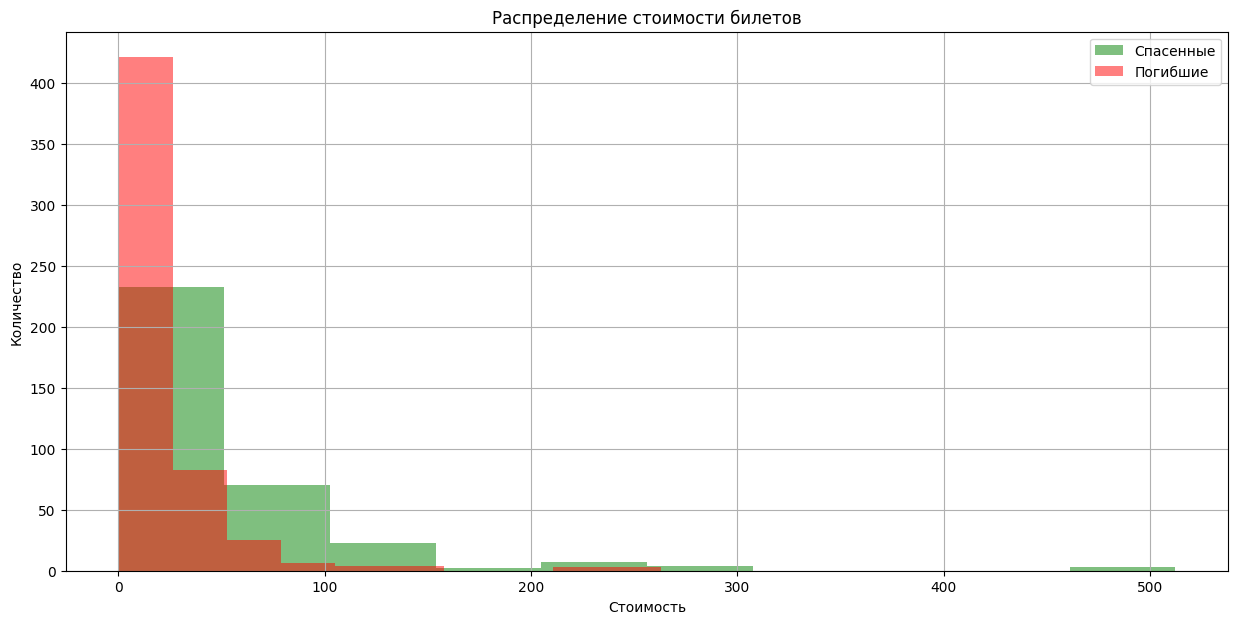

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,7))
data[data['Survived'] == 1]['Fare'].hist(color="green", label='Спасенные', alpha=0.5)
data[data['Survived'] == 0]['Fare'].hist(color="red", label='Погибшие', alpha=0.5)
plt.title('Распределение стоимости билетов')
plt.xlabel('Стоимость')
plt.ylabel('Количество')
plt.legend()
plt.show()


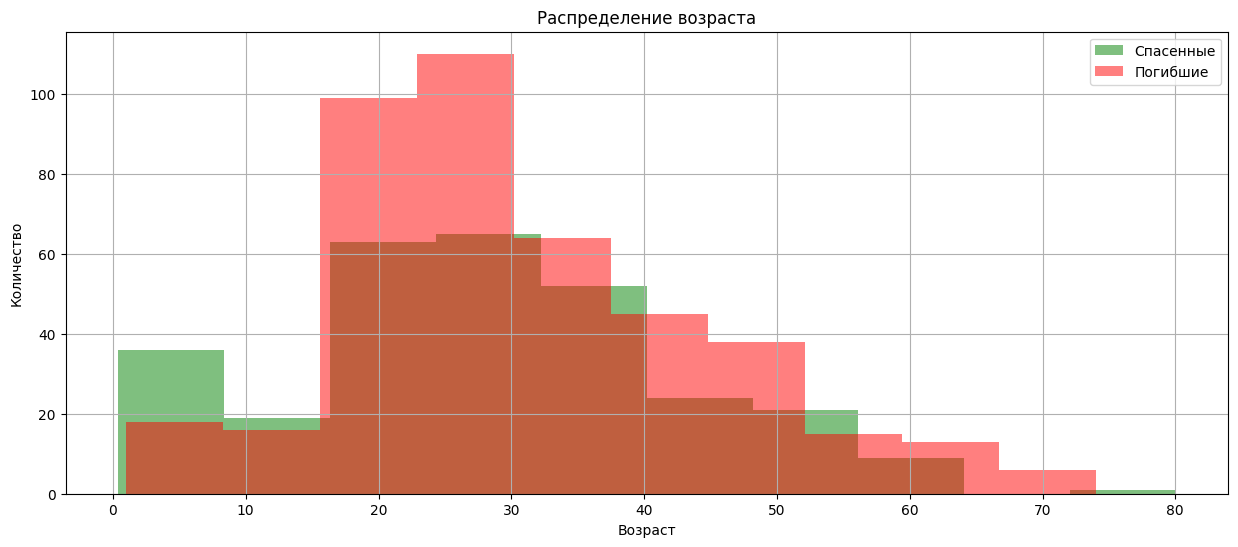

In [29]:
plt.figure(figsize=(15,6))
data[data['Survived'] == 1]['Age'].hist(color="green", label='Спасенные', alpha=0.5)
data[data['Survived'] == 0]['Age'].hist(color="red", label='Погибшие', alpha=0.5)
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.legend()
plt.show()


**8. Как отличается средний возраст мужчин / женщин в зависимости от класса обслуживания? Выберите верные утверждения:**
- В среднем мужчины 1-го класса старше 40 лет +
- В среднем женщины 1-го класса старше 40 лет
- Мужчины всех классов в среднем старше женщин того же класса +
- В среднем люди в 1 классе старше, чем во 2-ом, а те старше представителей 3-го класса +

In [ ]:
data.groupby(['Pclass', 'Sex']).agg({'Age':'mean'})

Age
Pclass Sex              
1      female  34.611765
       male    41.281386
2      female  28.722973
       male    30.740707
3      female  21.750000
       male    26.507589